In [1]:
!pip install -q langgraph langchain_google_genai langchain_community pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.9/323.9 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.9/469.9 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.3/208.3 kB 8.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take 

In [2]:
import getpass
import os

#Langchain mensajes
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage

#Langchain chat model (Google)
from langchain_google_genai import ChatGoogleGenerativeAI

#Langchain document loaders
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents.base import Document

#Langchain text splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter

#Message state
from langgraph.graph.message import MessagesState
from typing import TypedDict, Annotated
from langgraph.types import Send
import operator

#Workflow
from langgraph.graph import StateGraph, START, END
from langgraph.graph.state import CompiledStateGraph

from IPython.display import Image, display

In [3]:
# Ingresa el API key
os.environ["GOOGLE_API_KEY"]: str = getpass.getpass("Ingresa tu Google AI API key: ")

Ingresa tu Google AI API key: ··········


In [4]:
#Inicializamos nuestro modelo chat
llm: ChatGoogleGenerativeAI = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

In [5]:
class EstadoChunk(TypedDict):
    chunk: str

class EstadoGeneral(TypedDict):
    ruta_documento: str
    chunks: list[str]
    resumenes_parciales: Annotated[list[str], operator.add]
    resumen_final: str

In [14]:
def dividir_documento(state: EstadoGeneral):
    """
    Divide el documento PDF en fragmentos de texto (chunks).

    Carga el archivo PDF desde la ruta especificada en el estado,
    lo convierte en documentos de LangChain y los divide en fragmentos
    utilizando un separador jerárquico. Cada fragmento es almacenado
    como texto plano.

    Parámetros
    ----------
    state : EstadoGeneral
        Diccionario que contiene la ruta del documento PDF.

    Retorna
    -------
    dict
        Un diccionario con la clave "chunks" que contiene una lista de textos,
        cada uno representando un fragmento del documento.
    """
    loader: PyPDFLoader = PyPDFLoader(state["ruta_documento"])
    documento_pdf: list = loader.load()

    splitter: RecursiveCharacterTextSplitter = RecursiveCharacterTextSplitter(
        chunk_size=800,
        chunk_overlap=100,
        separators=["\n\n", "\n", ".", " "]
    )

    documentos: list[Document] = splitter.split_documents(documento_pdf)
    chunks: list[str] = [document.page_content for document in documentos]
    return {"chunks": chunks}


def resume_chunk(state: EstadoChunk):
    """
    Resume un fragmento de texto en 1 o 2 oraciones.

    Toma un solo fragmento proveniente del estado y genera un resumen
    corto utilizando el modelo de lenguaje configurado.

    Parámetros
    ----------
    state : EstadoChunk
        Diccionario que contiene el texto del fragmento en 'chunk'.

    Retorna
    -------
    dict
        Diccionario con la clave "resumenes_parciales" que contiene
        una lista con el resumen generado.
    """
    prompt: HumanMessage = HumanMessage(
        content=f"Resume este texto en 1 o 2 oraciones:\n\n{state['chunk']}"
    )
    respuesta: AIMessage = llm.invoke([prompt])
    return {"resumenes_parciales": [respuesta.content]}


def continuar_a_combinar_resumenes(state: EstadoGeneral):
    """
    Envía cada fragmento a la tarea de resumen.

    Genera una lista de objetos Send, uno por cada chunk disponible,
    para que el grafo ejecute la función `resume_chunk` en paralelo.

    Parámetros
    ----------
    state : EstadoGeneral
        Diccionario con la lista de fragmentos disponibles.

    Retorna
    -------
    list[Send]
        Lista de tareas Send a ejecutar.
    """
    return [ Send("resume_chunk", {"chunk": c}) for c in state["chunks"] ]


def combinar_resumenes(state: EstadoGeneral):
    """
    Combina todos los resúmenes parciales en uno solo.

    Recibe la lista de resúmenes parciales, construye un prompt con ellos
    y utiliza el modelo de lenguaje para producir un resumen final coherente.

    Parámetros
    ----------
    state : EstadoGeneral
        Diccionario que contiene la lista 'resumenes_parciales'.

    Retorna
    -------
    dict
        Diccionario con la clave "resumen_final" que contiene el resumen
        combinado.
    """
    texto: str = "Combina los siguientes resúmenes de fragmentos en un solo resumen coherente:\n\n"
    for s in state["resumenes_parciales"]:
        texto += f"- {s}\n"

    prompt: HumanMessage = HumanMessage(content=texto)
    respuesta: AIMessage = llm.invoke([prompt])
    return {"resumen_final": respuesta.content}


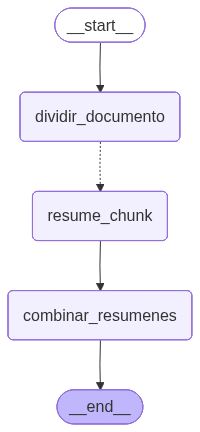

In [15]:
workflow: StateGraph = StateGraph(EstadoGeneral)

workflow.add_node("dividir_documento", dividir_documento)
workflow.add_node("resume_chunk", resume_chunk)
workflow.add_node("combinar_resumenes", combinar_resumenes)

workflow.set_entry_point("dividir_documento")
workflow.add_conditional_edges("dividir_documento", continuar_a_combinar_resumenes, ['resume_chunk'])
workflow.add_edge("resume_chunk", "combinar_resumenes")
workflow.add_edge("combinar_resumenes", END)

workflow_compilado_memoria: CompiledStateGraph = workflow.compile()
display(Image(workflow_compilado_memoria.get_graph().draw_mermaid_png()))

In [16]:
resultado: dict = workflow_compilado_memoria.invoke(
    {"ruta_documento": "/content/La_cultura_del_Perú.pdf",
    "chunks": [],
    "resumenes_parciales": []})

chunks: list = resultado['chunks']
resumenes_parciales: list = resultado['resumenes_parciales']
resumen_final: str = resultado['resumen_final']

In [17]:
print("=== RESÚMENES POR FRAGMENTO ===\n")

for i, (chunk, resumen) in enumerate(zip(chunks, resumenes_parciales), start=1):
    print(f"----- Fragmento #{i} -----")
    print(chunk)
    print("\n--- Resumen ---")
    print(resumen)
    print("\n")

print("=== RESUMEN FINAL ===\n")
print(resumen_final)

=== RESÚMENES POR FRAGMENTO ===

----- Fragmento #1 -----
La historia del Perú
El Perú ha tenido un desarrollo histórico amplio y nunca ajeno a los acontecimientos mundiales. La proyección e inﬂuencia 
cultural del Perú ha sido un factor de relevancia mayor en la Historia de América del Sur desde la expansión del Imperio 
Inca, seguido por la creación del Virreinato del Perú, hasta la fundación de la República en 1821. Desde la llegada de los 
primeros pobladores hasta nuestros días, el Perú se ha nutrido y fortalecido con la vertiente andina, española, africana, 
china, japonesa e italiana, generando una sociedad multicultural y multiétnica de rápida adecuación a nuevos tiempos, 
caracterizada por una gran receptividad ante lo foráneo, llegando a crear uno de los focos culturales más importantes de

--- Resumen ---
La historia del Perú se caracteriza por su amplio desarrollo y gran influencia cultural en Sudamérica, desde el Imperio Inca hasta la República. Su sociedad es multicultura